In [1]:
import numpy as np
from scipy.interpolate import BSpline
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm, LogNorm

import warnings
warnings.filterwarnings('ignore')

C_PURPLE ='#7F77DD'
C_CORAL ='#D85A30'
C_TEAL ='#1D9E75'
C_AMBER ='#EF9F27'
C_BLUE ='#378ADD'

In [2]:
def build_bspline_basis(t, n_knots=20, degree=3):
    internal_knots = np.linspace(0, 1, n_knots)
    knots = np.concatenate([
        np.repeat(0.0, degree),
        internal_knots,
        np.repeat(1.0, degree),
    ])
    nbasis = len(knots) - degree - 1
    basis_list = []
    for i in range(nbasis):
        c = np.zeros(nbasis)
        c[i] = 1.0
        sp = BSpline(knots, c, degree, extrapolate=False)
        basis_list.append(sp(t))
    B = np.nan_to_num(np.asarray(basis_list).T)
    return B, knots

In [4]:
# Synthetic TOD parameters
nsamp = 2000
tau = 36
n_knots = 20
degree = 3
f_hwp = 2.1 # Hz
f_s = 200.0 # Hz
harmonic = 4

t_norm = np.linspace(0, 1, nsamp)
t_sec = np.linspace(0, nsamp / f_s, nsamp)
hwp_ang = 2 * np.pi * f_hwp * t_sec # HWP angle in rad

In [5]:
## build basis
B, knots = build_bspline_basis(t_norm, n_knots=n_knots, degree=degree)
nbasis= B.shape[1]

In [6]:
# Design matrix T3
c4 = np.cos(harmonic * hwp_ang)
s4 = np.sin(harmonic * hwp_ang)
cols = []
for i in range(nbasis):
    cols.append(B[:, i] * c4)
    cols.append(B[:, i] * s4)
T3 = np.column_stack(cols)

In [7]:
n_blocks = nsamp // tau
def apply_DT1(v):
    out = v.copy()
    for b in range(n_blocks):
        s1 = slice(b*tau, (b+1)*tau)
        out[s1] -= out[s1].mean()
    return out

In [8]:
## Orthogonalised spline T3_tilde = D_{T1} T3
T3_tilde = np.column_stack([apply_DT1(T3[:,j]) for j in range(T3.shape[1])])

In [9]:
## Gram matrices
GramT3 = T3.T @ T3
GramT3_tilde = T3_tilde.T @ T3_tilde # orthogonalised

In [10]:
# synthetic HWPSS signal for residual panel
rng = np.random.default_rng(42)
A_true = 0.5 * np.sin(2 * np.pi * t_norm * 3) + 0.3
B_true = 0.3 * np.cos(2 * np.pi * t_norm * 2) - 0.1
noise = rng.standard_normal(nsamp) * 0.05
drift = np.cumsum(rng.standard_normal(nsamp)) * 0.002
signal = A_true * c4 + B_true * s4 + noise + drift

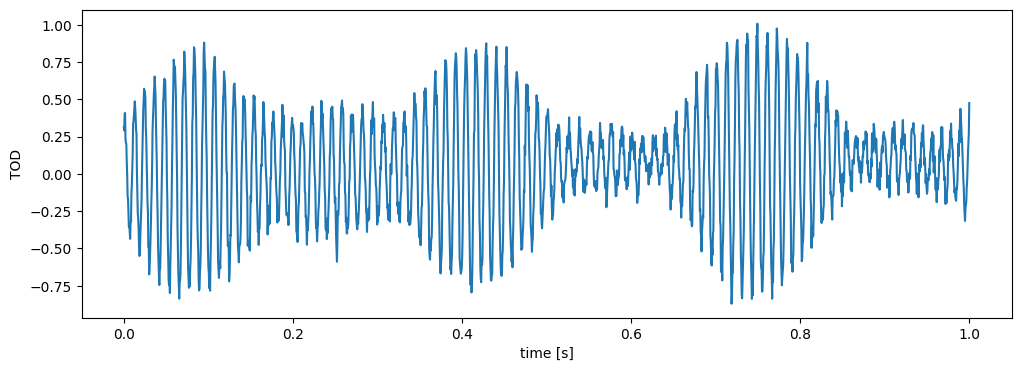

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(t_norm, signal)

plt.xlabel("time [s]")
plt.ylabel("TOD")
plt.show()

In [11]:
# Fit with T3_tilde
AtA = T3_tilde.T @ T3_tilde + 1e-6 * np.eye(2*nbasis) # ridge regularization
rhs = T3_tilde.T @ signal
coeffs = np.linalg.solve(AtA, rhs)
model_tilde = T3_tilde @ coeffs
residual = signal - model_tilde

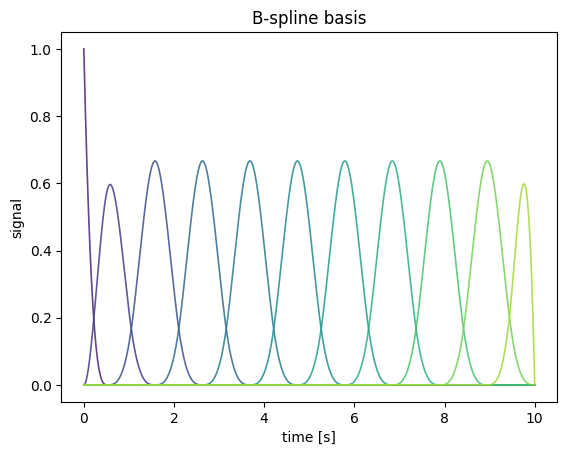

In [ ]:
#| label: bspline_basis
cmap_b = plt.cm.viridis(np.linspace(0.1, 0.9, nbasis))
show_every = max(1, nbasis // 10)

for i in range(0, nbasis, show_every):
    plt.plot(t_sec, B[:, i], color=cmap_b[i], lw=1.2, alpha=0.85)

plt.xlabel("time [s]")
plt.ylabel("signal")
plt.title("B-spline basis")
plt.show()

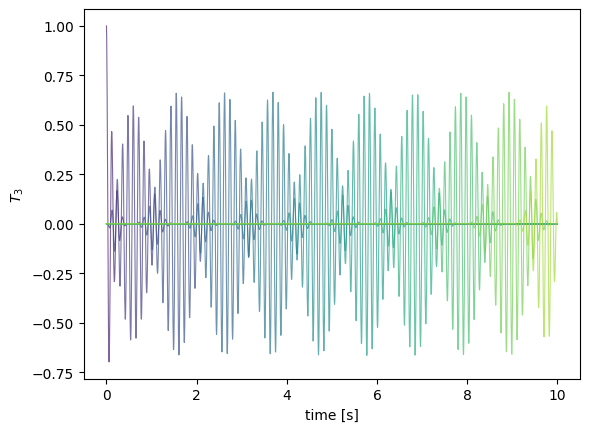

In [ ]:
#| label: T_3

for i in range(0, nbasis, show_every):
    plt.plot(t_sec, T3[:, 2*i], color=cmap_b[i], lw=0.8, alpha=0.7)

plt.xlabel("time [s]")
plt.ylabel("$T_3$")
plt.show()

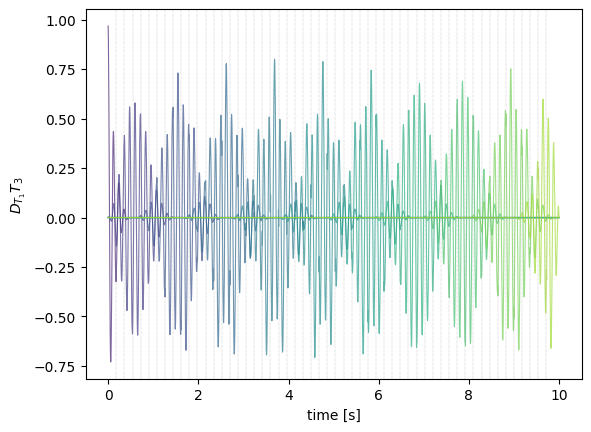

In [ ]:
#| label: T_3_ortho
for i in range(0, nbasis, show_every):
    plt.plot(t_sec, T3_tilde[:, 2*i], color=cmap_b[i], lw=0.8, alpha=0.7)

for b in range(1, n_blocks):
    plt.axvline(b * tau / f_s, color="gray", lw=0.35, ls=":", alpha=0.8)
    
plt.xlabel('time [s]')
plt.ylabel('$D_{T_1} T_3$')

plt.show()

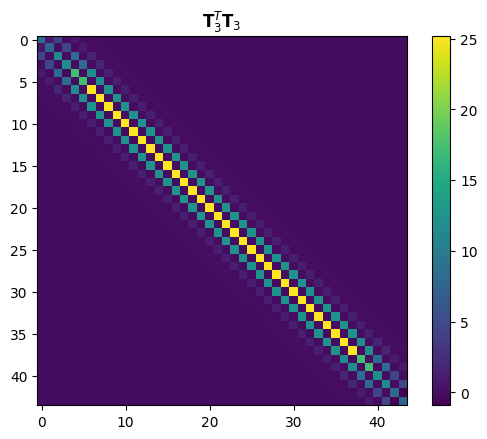

In [35]:
plt.imshow(GramT3)
plt.colorbar()

plt.title(r"$\mathbf{T}_3^T \mathbf{T}_3$")
plt.show()

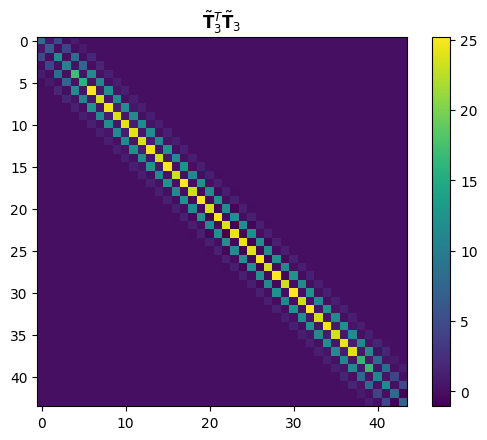

In [31]:
#| label: AtA_ortho
plt.imshow(AtA)
plt.colorbar()

plt.title(r"$\mathbf{\tilde{T}}_3^T \mathbf{\tilde{T}}_3$")
plt.show()

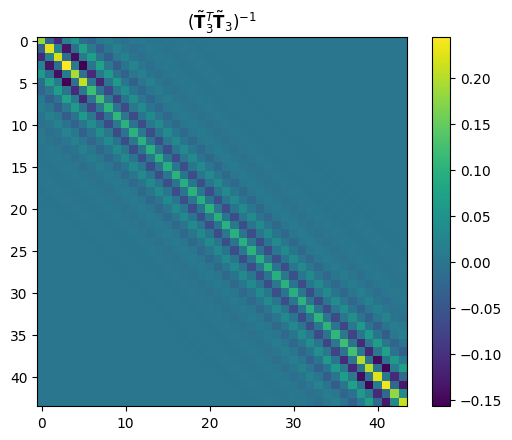

In [ ]:
#| label: AtA_ortho_inv
plt.imshow(np.linalg.inv(AtA))

plt.colorbar()
plt.title(r"$(\mathbf{\tilde{T}}_3^T \mathbf{\tilde{T}}_3)^{-1}$")

plt.show()

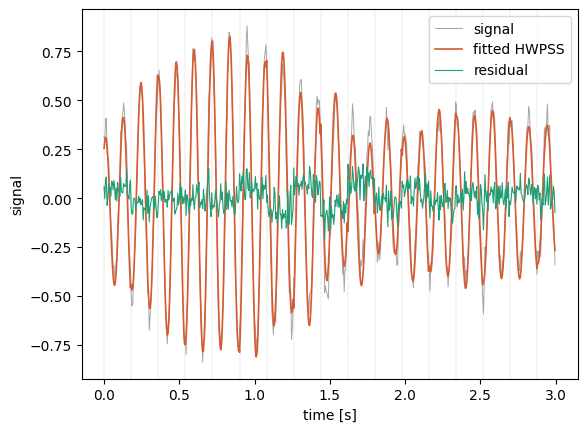

In [ ]:
#| label: demo_T3
show = slice(0, min(600, nsamp))
plt.plot(t_sec[show], signal[show], color='gray', lw=0.7, alpha=0.7, label='signal')
plt.plot(t_sec[show], model_tilde[show], color=C_CORAL, lw=1.2, label='fitted HWPSS')

plt.plot(t_sec[show], residual[show], color=C_TEAL, lw=0.8, label=f'residual')

for b in range(show.stop // tau + 1):
    plt.axvline(b * tau / f_s, color="gray", lw=0.35, ls=":", alpha=0.8)
    
plt.xlabel("time [s]")
plt.ylabel("signal")
plt.legend()

plt.show()